In [33]:
import numpy as np
from matplotlib.pyplot import *
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.utils import to_categorical

In [24]:
iris = load_iris()
x = iris.data
y = iris.target
feature_names = iris['feature_names']
target_names = iris['target_names']
n_epoch = 300
print('Feature names are ', feature_names)
print('Target names are ', target_names)
print('Epoch count is ', n_epoch)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

Feature names are  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names are  ['setosa' 'versicolor' 'virginica']
Epoch count is  300


In [25]:
# Iris Classification using Integer Labels
model = Sequential()
model.add(Dense(100, activation='relu', input_shape=(4,)))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=[SparseCategoricalAccuracy(name="acc")])
h1 = model.fit(x_train, y_train, epochs=n_epoch, validation_split=0.2)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 468ms/step - acc: 0.3438 - loss: 1.4671 - val_acc: 0.2500 - val_loss: 1.3874
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - acc: 0.3359 - loss: 1.2411 - val_acc: 0.2500 - val_loss: 1.1734
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - acc: 0.3438 - loss: 1.0857 - val_acc: 0.2500 - val_loss: 1.0343
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - acc: 0.4935 - loss: 0.9925 - val_acc: 0.7500 - val_loss: 0.9523
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - acc: 0.6484 - loss: 0.9609 - val_acc: 0.7500 - val_loss: 0.9021
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - acc: 0.6641 - loss: 0.9301 - val_acc: 0.7500 - val_loss: 0.8673
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - acc: 0.6484 - loss: 0.9209 - val_acc: 0.7500 - val_loss: 0.8386
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - acc: 0.6758 - loss: 0.8606 - val_acc: 0.7500 - val_loss: 0.8132
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - acc: 0.6836 -

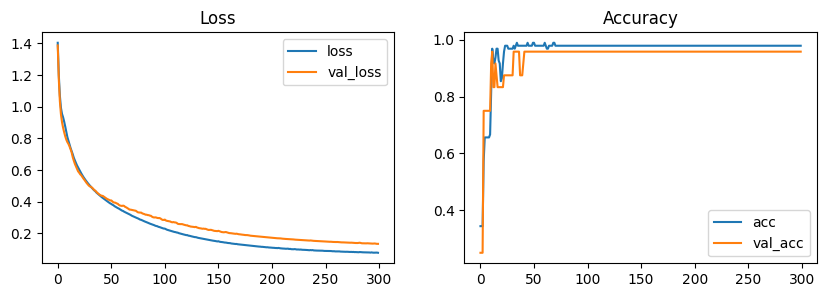

In [26]:
figure(figsize=(10,3))
subplot(121)
title('Loss')
plot(h1.epoch, h1.history['loss'], h1.epoch, h1.history['val_loss'])
legend(['loss','val_loss'])

subplot(122)
title('Accuracy')
plot(h1.epoch, h1.history['acc'], h1.epoch, h1.history['val_acc'])
legend(['acc','val_acc'])

show()

In [27]:
# Iris Classification using 1-Hot Labels
y_train = to_categorical(y_train) # convert labels to 1-hot

model = Sequential()
model.add(Dense(100, activation='relu', input_shape=(4,)))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["acc"])
h2 = model.fit(x_train, y_train, epochs=n_epoch, validation_split=0.2)

Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - acc: 0.3307 - loss: 1.9458 - val_acc: 0.3750 - val_loss: 1.7284
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.3464 - loss: 1.6567 - val_acc: 0.3750 - val_loss: 1.4878
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - acc: 0.3385 - loss: 1.3845 - val_acc: 0.3750 - val_loss: 1.3123
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - acc: 0.4062 - loss: 1.1120 - val_acc: 0.6250 - val_loss: 1.1895
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.7370 - loss: 1.0379 - val_acc: 0.6250 - val_loss: 1.0935
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - acc: 0.7565 - loss: 0.9512 - val_acc: 0.6250 - val_loss: 1.0117
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - acc: 0.6810 - loss: 0.9517 - val_acc: 0.6250 - val_loss: 0.9414
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.6654 - loss: 0.9153 - val_acc: 0.7083 - val_loss: 0.8863
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - acc: 0.9115 - los

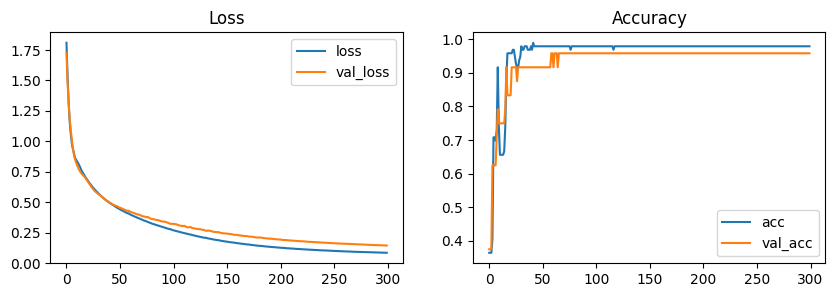

In [28]:
figure(figsize=(10,3))
subplot(121)
title('Loss')
plot(h2.epoch, h2.history['loss'], h2.epoch, h2.history['val_loss'])
legend(['loss','val_loss'])

subplot(122)
title('Accuracy')
plot(h2.epoch, h2.history['acc'], h2.epoch, h2.history['val_acc'])
legend(['acc','val_acc'])

show()

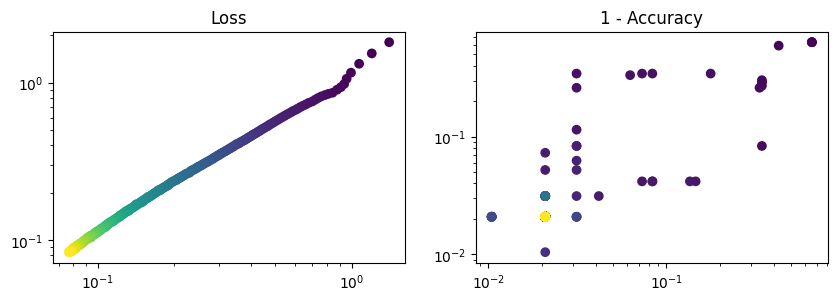

In [42]:
# Extra plot
figure(figsize=(10,3))

subplot(121)
title('Loss')
scatter(h1.history['loss'], h2.history['loss'], c=h1.epoch)
xscale('log'); yscale('log')

subplot(122)
title('1 - Accuracy')
scatter(1 - np.array(h1.history['acc']), 1 - np.array(h2.history['acc']), c=h1.epoch)
xscale('log'); yscale('log')

show()

(150, 4) (150,) [0 0 0 0 0]


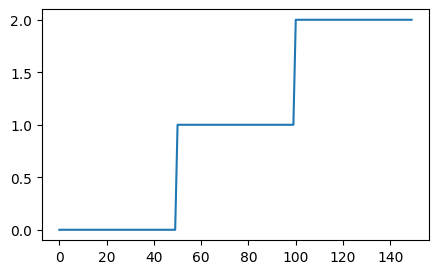

In [45]:
# Binary classification for class 0-1 and class 2
print(x.shape, y.shape, y[:5])
figure(figsize=(5,3))
plot(y)
show()

In [48]:
# Train-test split (Only the first 100 samples)
x1, y1 = x[:100,:], y[:100]
x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.2)

In [50]:
# Logistic regression
model = Sequential()
model.add(Dense(1, activation='sigmoid', input_shape=(4,)))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=['accuracy'])
h3 = model.fit(x_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 763ms/step - accuracy: 0.8125 - loss: 0.3887 - val_accuracy: 0.5625 - val_loss: 0.4883
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8750 - loss: 0.4017 - val_accuracy: 0.7500 - val_loss: 0.4822
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8958 - loss: 0.4028 - val_accuracy: 0.7500 - val_loss: 0.4761
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9583 - loss: 0.4072 - val_accuracy: 0.7500 - val_loss: 0.4700
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9688 - loss: 0.3988 - val_accuracy: 0.7500 - val_loss: 0.4640
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9792 - loss: 0.4014 - val_accuracy: 0.7500 - val_loss: 0.4582
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9583 - loss: 0.4014 - val_accuracy: 0.8750 - val_loss: 0.4525
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 1.0000 - loss: 0.3982 - val_accuracy: 0.9375 - v

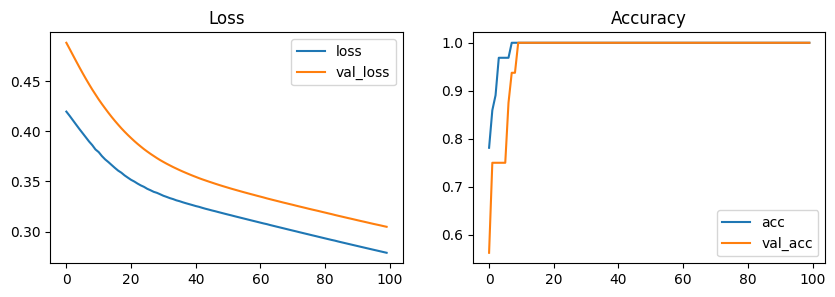

In [51]:
figure(figsize=(10,3))
subplot(121)
title('Loss')
plot(h3.epoch, h3.history['loss'], h3.epoch, h3.history['val_loss'])
legend(['loss','val_loss'])

subplot(122)
title('Accuracy')
plot(h3.epoch, h3.history['accuracy'], h3.epoch, h3.history['val_accuracy'])
legend(['acc','val_acc'])

show()

In [52]:
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 1.0000 - loss: 0.2923


[0.2922991216182709, 1.0]

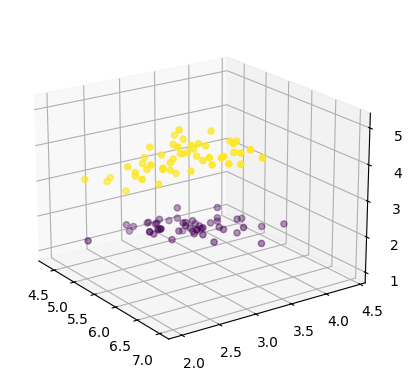

In [66]:
fig = figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x1[:,0], x1[:,1], x1[:,2], c=y1)
ax.view_init(elev=20., azim=-35, roll=0)